# Conformal Prediction Under Distribution Shift

Standard conformal prediction assumes data is exchangeable (i.i.d.). Under distribution shift, coverage guarantees break — intervals may be too narrow or too wide.

**Weighted Conformal:** Re-weights calibration scores by importance weights w(x) = p_test(x)/p_cal(x), restoring marginal coverage under covariate shift.

**Adaptive Conformal:** Updates the prediction threshold online as new test points arrive. If coverage drops below target, thresholds widen; if above, they narrow. Provides approximate coverage guarantees even under gradual shift.

**Reference:** Tibshirani et al. (2019); Gibbs & Candès (2021)

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from deepuq.methods.conformal import (
    SplitConformalRegressor,
    WeightedConformalPredictor,
    AdaptiveConformalPredictor,
)

## Generate Data with Covariate Shift

**Covariate shift** occurs when the test input distribution p_test(x) differs from training p_train(x), while the conditional p(y|x) remains the same. Standard conformal prediction relies on exchangeability, so when calibration and test data come from different distributions, the calibration quantile no longer guarantees coverage on the test set.

Train x mean: 0.01, Test x mean: 2.11


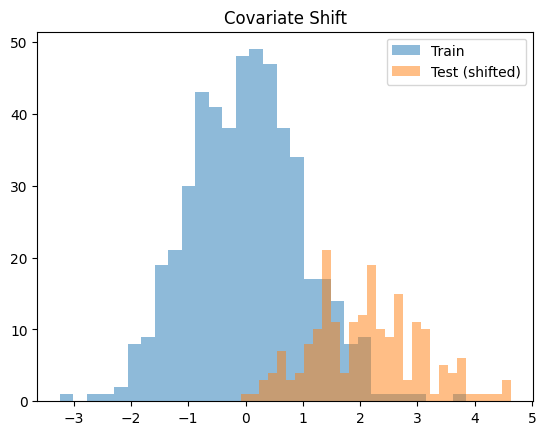

In [2]:
np.random.seed(42)
torch.manual_seed(42)

# Training/calibration data from N(0, 1)
n_train, n_cal, n_test = 500, 200, 200
x_train = np.random.randn(n_train, 1).astype(np.float32)
x_cal = np.random.randn(n_cal, 1).astype(np.float32)

# Test data from N(2, 1) -- shifted distribution
x_test = np.random.randn(n_test, 1).astype(np.float32) + 2.0

# True function: y = sin(x) + noise
def true_fn(x):
    return np.sin(x)

noise_std = 0.2
y_train = true_fn(x_train) + noise_std * np.random.randn(n_train, 1).astype(np.float32)
y_cal = true_fn(x_cal) + noise_std * np.random.randn(n_cal, 1).astype(np.float32)
y_test = true_fn(x_test) + noise_std * np.random.randn(n_test, 1).astype(np.float32)

print(f"Train x mean: {x_train.mean():.2f}, Test x mean: {x_test.mean():.2f}")
plt.hist(x_train, alpha=0.5, label="Train", bins=30)
plt.hist(x_test, alpha=0.5, label="Test (shifted)", bins=30)
plt.legend()
plt.title("Covariate Shift")
plt.show()

## Standard Conformal (Breaks Under Shift)

In [3]:
# Simple MLP model
import torch.nn as nn

class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, 1),
        )
    def forward(self, x):
        return self.net(x)

model = SimpleMLP()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
X_tr = torch.from_numpy(x_train)
Y_tr = torch.from_numpy(y_train)

# Train
for epoch in range(500):
    pred = model(X_tr)
    loss = nn.functional.mse_loss(pred, Y_tr)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print(f"Final training loss: {loss.item():.4f}")

# Standard split conformal on calibration set
X_cal_t = torch.from_numpy(x_cal)
Y_cal_t = torch.from_numpy(y_cal)
X_test_t = torch.from_numpy(x_test)
Y_test_t = torch.from_numpy(y_test)

from torch.utils.data import TensorDataset
cal_data = TensorDataset(X_cal_t, Y_cal_t)

conformal = SplitConformalRegressor(model, alpha=0.1)
conformal.calibrate(cal_data)

# Predict on shifted test set (returns UQResult)
result = conformal.predict_uq(X_test_t)
lower = result.metadata["conformal_lower"]
upper = result.metadata["conformal_upper"]
coverage = ((Y_test_t.squeeze() >= lower) & (Y_test_t.squeeze() <= upper)).float().mean().item()
print(f"Standard conformal coverage on shifted test: {coverage:.3f} (target: 0.90)")

Final training loss: 0.0370
Standard conformal coverage on shifted test: 0.910 (target: 0.90)


## Weighted Conformal Prediction

In [4]:
# Compute importance weights via density ratio p_test(x) / p_train(x)
# p_train ~ N(0,1), p_test ~ N(2,1)
from scipy.stats import norm

def density_ratio(x, mu_train=0.0, mu_test=2.0, sigma=1.0):
    """Likelihood ratio p_test(x) / p_train(x)."""
    return norm.pdf(x, loc=mu_test, scale=sigma) / norm.pdf(x, loc=mu_train, scale=sigma)

# Weights for calibration points
cal_weights = density_ratio(x_cal.flatten())
cal_weights = cal_weights / cal_weights.sum()  # normalize
cal_weights_t = torch.from_numpy(cal_weights.astype(np.float32))

# Weighted conformal prediction
weighted_conformal = WeightedConformalPredictor(model)
weighted_conformal.calibrate(X_cal_t, Y_cal_t, weights=cal_weights_t)

lower_w, upper_w = weighted_conformal.predict_set(X_test_t, alpha=0.1)
coverage_w = ((Y_test_t.squeeze() >= lower_w) & (Y_test_t.squeeze() <= upper_w)).float().mean().item()
print(f"Weighted conformal coverage on shifted test: {coverage_w:.3f} (target: 0.90)")

Weighted conformal coverage on shifted test: 0.875 (target: 0.90)


## Adaptive Conformal Prediction

Adaptive conformal prediction maintains a threshold updated online via the rule: q_{t+1} = q_t + gamma*(alpha - err_t), where err_t is 1 if the true label fell outside the interval and 0 otherwise. This feedback loop widens intervals when coverage is below target and narrows them when above, converging to the desired coverage rate even under gradual distribution shift.

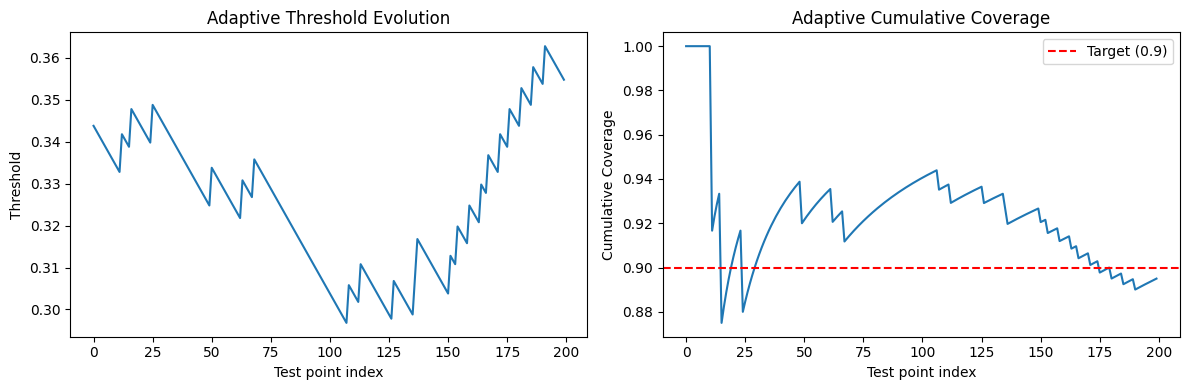

In [5]:
# Adaptive conformal: updates threshold sequentially
adaptive = AdaptiveConformalPredictor(model, target_coverage=0.9, gamma=0.01)
adaptive.calibrate(X_cal_t, Y_cal_t)

coverages_list = []
thresholds_list = []

for i in range(len(X_test_t)):
    xi = X_test_t[i:i+1]
    yi = Y_test_t[i:i+1]

    lo, hi = adaptive.predict_set(xi)
    covered = (yi.squeeze() >= lo) & (yi.squeeze() <= hi)
    coverages_list.append(covered.item())
    thresholds_list.append(adaptive.threshold)

    # Update with true label
    adaptive.update(xi, yi)

cumulative_coverage = np.cumsum(coverages_list) / (np.arange(len(coverages_list)) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(thresholds_list)
axes[0].set_xlabel("Test point index")
axes[0].set_ylabel("Threshold")
axes[0].set_title("Adaptive Threshold Evolution")

axes[1].plot(cumulative_coverage)
axes[1].axhline(0.9, color="r", linestyle="--", label="Target (0.9)")
axes[1].set_xlabel("Test point index")
axes[1].set_ylabel("Cumulative Coverage")
axes[1].set_title("Adaptive Cumulative Coverage")
axes[1].legend()
plt.tight_layout()
plt.show()

## Compare Coverage

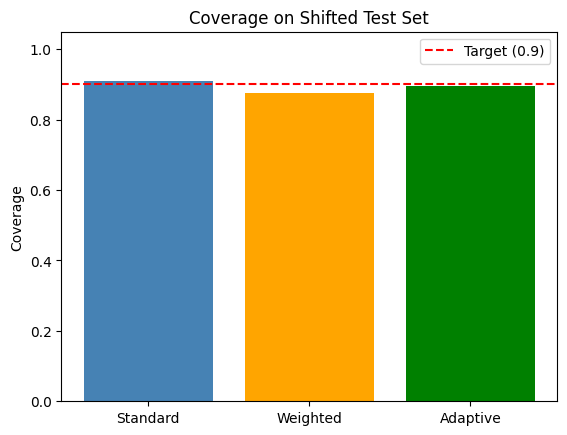

Standard: 0.910
Weighted: 0.875
Adaptive: 0.895


In [6]:
adaptive_final_coverage = cumulative_coverage[-1]

methods = ["Standard", "Weighted", "Adaptive"]
coverages_all = [coverage, coverage_w, adaptive_final_coverage]

plt.bar(methods, coverages_all, color=["steelblue", "orange", "green"])
plt.axhline(0.9, color="r", linestyle="--", label="Target (0.9)")
plt.ylabel("Coverage")
plt.title("Coverage on Shifted Test Set")
plt.legend()
plt.ylim(0, 1.05)
plt.show()

for m, c in zip(methods, coverages_all):
    print(f"{m}: {c:.3f}")